### Fish velocity calculation from trajectories
To calculate the velocity of the fish from the $x$ and $y$ locations, you need to compute the displacement between consecutive points (Delta x, \Delta y) and divide by the corresponding time interval (\Delta t). 
Velocity Calculation: 
$$V=\frac{\sqrt(\Delta x^2+\Delta y^2)}{\Delta t}$$

First few rows of the dataset:
       x       y
0  4.927 -0.2992
1  5.278 -0.2992
2  5.044 -0.3672
3  5.044 -0.4896
4  5.044 -0.4896

First few rows with velocity calculation:
       x       y     dx      dy     dt  velocity   direction
0  4.927 -0.2992    NaN     NaN  0.037       NaN         NaN
1  5.278 -0.2992  0.351  0.0000  0.037  9.486486    0.000000
2  5.044 -0.3672 -0.234 -0.0680  0.037  6.585949 -163.796226
3  5.044 -0.4896  0.000 -0.1224  0.037  3.308108  -90.000000
4  5.044 -0.4896  0.000  0.0000  0.037  0.000000    0.000000


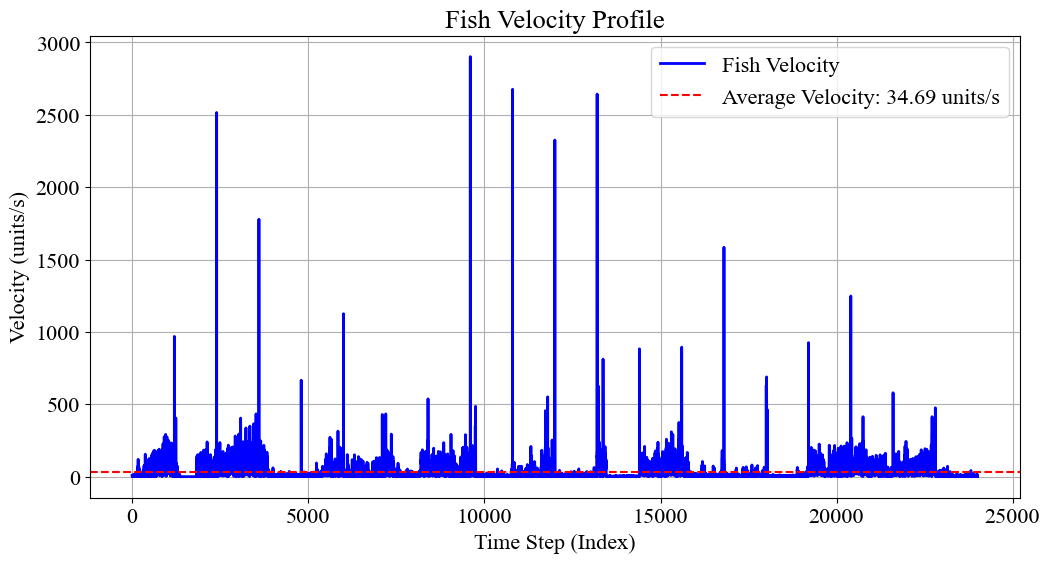


Velocity results saved to 'fish_velocity_output-MS.xlsx'.


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Excel file (replace 'fish_locations.xlsx' with your actual file name)
file_path = 'MS.xlsx'  # Update with your file path
df = pd.read_excel(file_path)

# Display the first few rows to verify the data structure
print("First few rows of the dataset:")
print(df.head())

# Ensure the DataFrame has 'x' and 'y' columns
if 'x' not in df.columns or 'y' not in df.columns:
    raise ValueError("The Excel file must contain 'x' and 'y' columns.")

# Calculate displacement between consecutive points
df['dx'] = df['x'].diff()
df['dy'] = df['y'].diff()

# If time data is available, use it; otherwise, assume constant time step
if 'time' in df.columns:
    df['dt'] = df['time'].diff()
else:
    time_step = 0.037  # framerate f=27 Hz, dt=1/f
    df['dt'] = time_step

# Calculate velocity magnitude (in units per second)
df['velocity'] = np.sqrt(df['dx']**2 + df['dy']**2) / df['dt']

# Calculate movement direction (angle in degrees)
df['direction'] = np.degrees(np.arctan2(df['dy'], df['dx']))

# Display the first few rows with calculated velocity
print("\nFirst few rows with velocity calculation:")
print(df[['x', 'y', 'dx', 'dy', 'dt', 'velocity', 'direction']].head())

# Plot the velocity profile
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['velocity'], color='b', linewidth=2, label='Fish Velocity')
plt.axhline(y=df['velocity'].mean(), color='r', linestyle='--', label=f'Average Velocity: {df["velocity"].mean():.2f} units/s')
plt.xlabel('Time Step (Index)')
plt.ylabel('Velocity (units/s)')
plt.title('Fish Velocity Profile')
plt.legend()
plt.grid(True)
plt.show()

# Save the results to a new Excel file
output_file = 'fish_velocity_output-MS.xlsx'
df.to_excel(output_file, index=False)
print(f"\nVelocity results saved to '{output_file}'.")


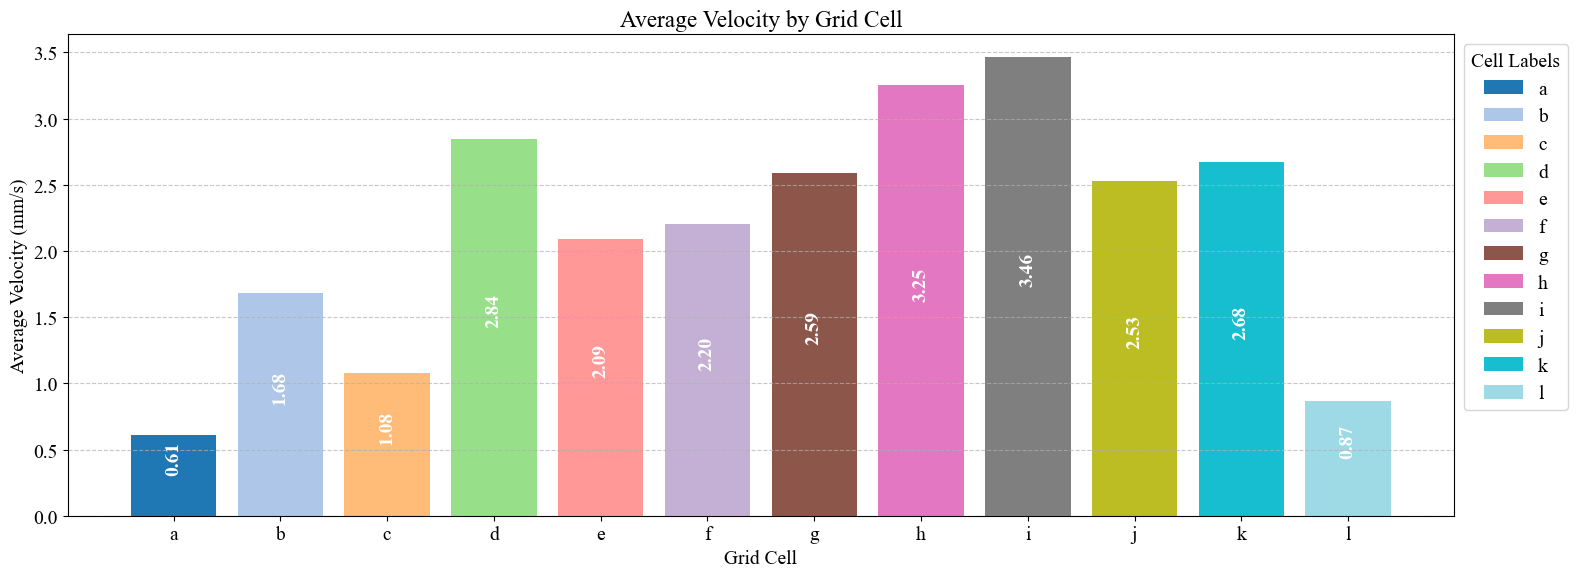

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import string

# Set the font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14

# Load data
file_path = "fish_velocity_output.xlsx"
df = pd.read_excel(file_path)

# Create bins and labels
x_bins = np.linspace(0, 120, 5)  # 4 columns
y_bins = np.linspace(0, 30, 4)    # 3 rows

# Create categorical bins
df['x_bin'] = pd.cut(df['x'], bins=x_bins, labels=[1, 2, 3, 4])
df['y_bin'] = pd.cut(df['y'], bins=y_bins, labels=[1, 2, 3])

# Calculate average velocities
grid_avg = df.groupby(['x_bin', 'y_bin'])['velocity'].mean().reset_index()

# Create sequential labels a-l in column-major order
labels = list(string.ascii_lowercase[:12])  # a-l
grid_avg['label'] = labels

# Sort the data for proper plotting
grid_avg = grid_avg.sort_values(['x_bin', 'y_bin'])

# Create the plot
plt.figure(figsize=(16, 6))

# Create bars with distinct colors
colors = plt.cm.tab20(np.linspace(0, 1, len(grid_avg)))

for idx, (label, velocity) in enumerate(zip(grid_avg['label'], grid_avg['velocity'])):
    plt.bar(idx, velocity, color=colors[idx], label=label)

# Customize plot
plt.title('Average Velocity by Grid Cell')
plt.xlabel('Grid Cell')
plt.ylabel('Average Velocity (mm/s)')
plt.xticks(range(len(grid_avg)), grid_avg['label'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add labels to each bar
for idx, velocity in enumerate(grid_avg['velocity']):
    plt.text(idx, velocity/2, f'{velocity:.2f}', 
            ha='center', va='bottom', rotation=90, 
            color='white', fontweight='bold')

plt.legend(title='Cell Labels', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

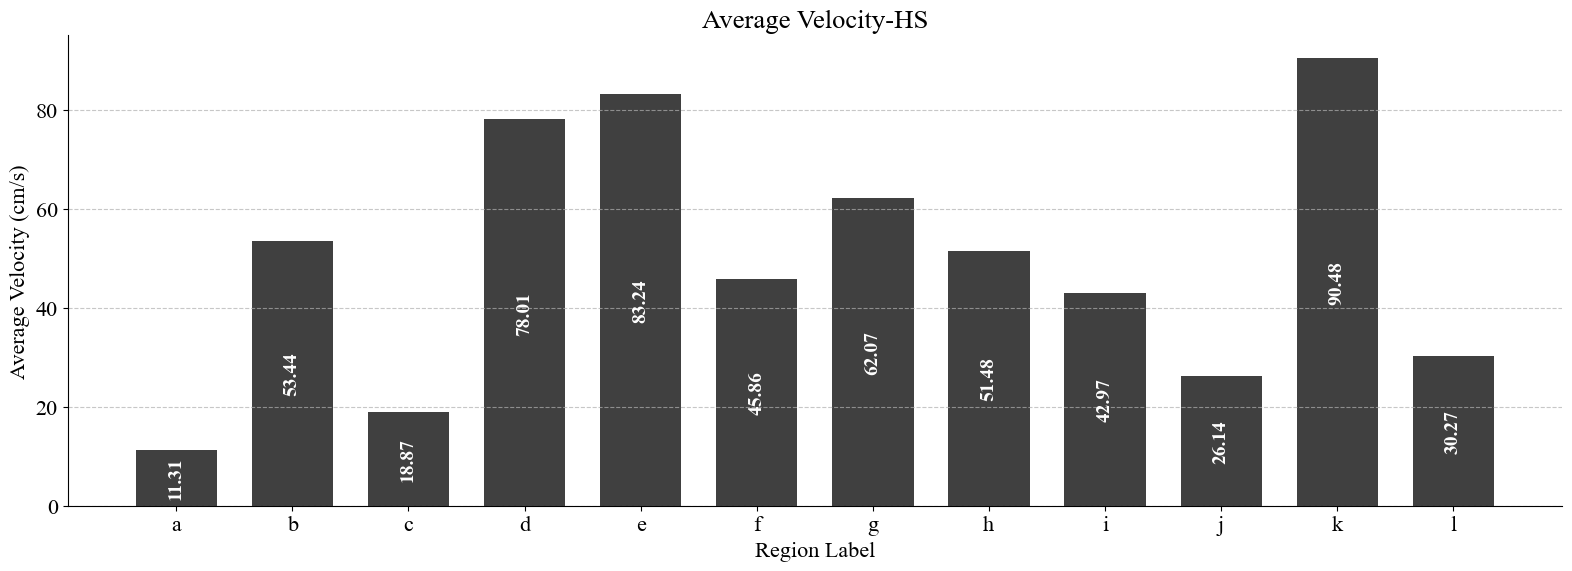

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import string

# Set the font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 16

# Load data
file_path = "fish_velocity_output-HS.xlsx"
df = pd.read_excel(file_path)

# Create bins and labels (now in cm)
x_bins = np.linspace(0, 120, 5)  # 0-120 cm (4 divisions)
y_bins = np.linspace(0, 30, 4)    # 0-30 cm (3 divisions)

# Create categorical bins
df['x_bin'] = pd.cut(df['x'], bins=x_bins, labels=[1, 2, 3, 4])
df['y_bin'] = pd.cut(df['y'], bins=y_bins, labels=[1, 2, 3])

# Calculate average velocities
grid_avg = df.groupby(['x_bin', 'y_bin'])['velocity'].mean().reset_index()

# Create sequential labels a-l in column-major order
labels = list(string.ascii_lowercase[:12])  # a-l
grid_avg['label'] = labels

# Sort the data for proper plotting (column-major order)
grid_avg = grid_avg.sort_values(['x_bin', 'y_bin'])

# Create the plot
plt.figure(figsize=(16, 6))

# Create all bars in gray
plt.bar(range(len(grid_avg)), 
        grid_avg['velocity'], 
        color='#404040',  # Dark gray
        width=0.7)

# Customize plot
plt.title('Average Velocity-HS')
plt.xlabel('Region Label')
plt.ylabel('Average Velocity (cm/s)')
plt.xticks(range(len(grid_avg)), grid_avg['label'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for idx, velocity in enumerate(grid_avg['velocity']):
    plt.text(idx, velocity/2, f'{velocity:.2f}', 
            ha='center', va='center', 
            rotation=90, color='white', fontweight='bold', fontsize=14)

# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'fish-velocity-HS.png', dpi=300, bbox_inches='tight')
plt.show()